Dataset Shape: (1599, 12)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Model Performance Comparison:

                 Model  Accuracy       AUC  Precision    Recall  F1 Score  \
0  Logistic Regression  0.733333  0.824327   0.754941  0.743191  0.749020   
1        Decision Tree  0.779167  0.777163   0.787072  0.805447  0.796154   
2                  KNN  0.731250  0.797247   0.744275  0.758755  0.751445   
3          Naive Bayes  0.722917  0.797979   0.767241  0.692607  0.728016   
4        Random Forest  0.797917  0.877676   0.807692  0.817121  0.812379   

        MCC  
0  0.464678  
1  0.555491  
2  0.459088  
3  0.449573  
4  0.593480  


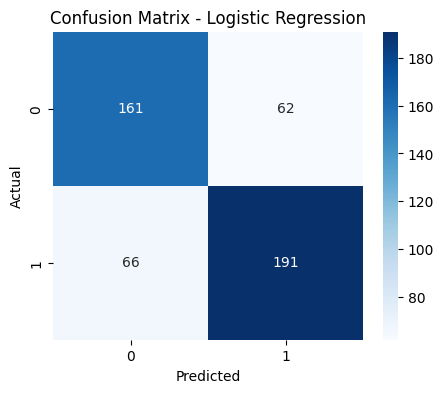

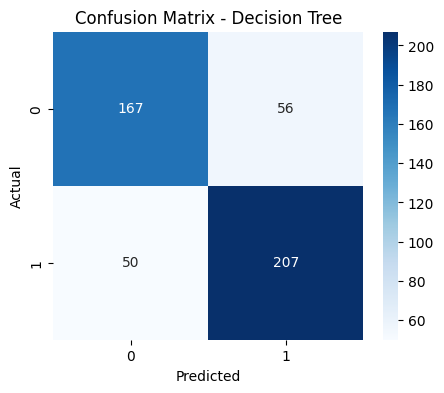

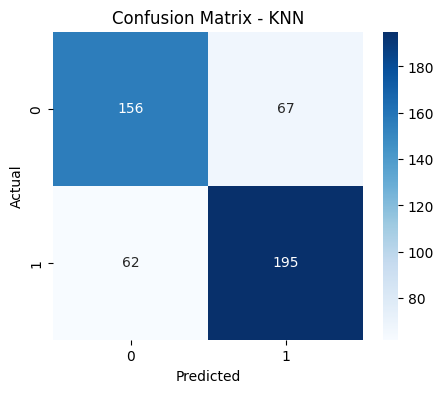

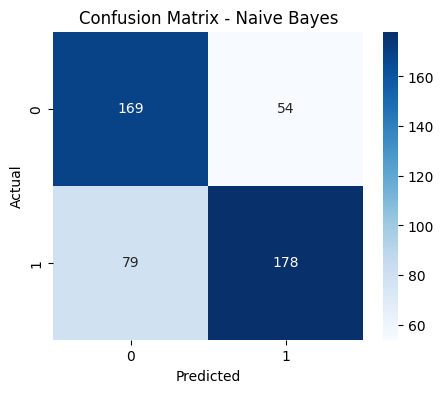

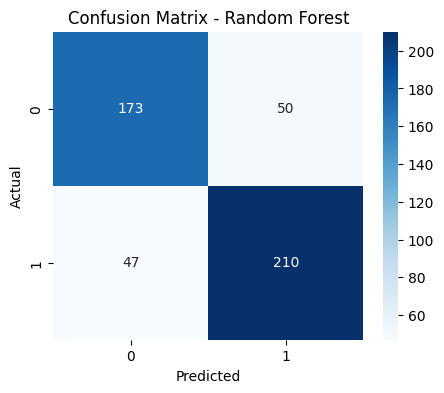

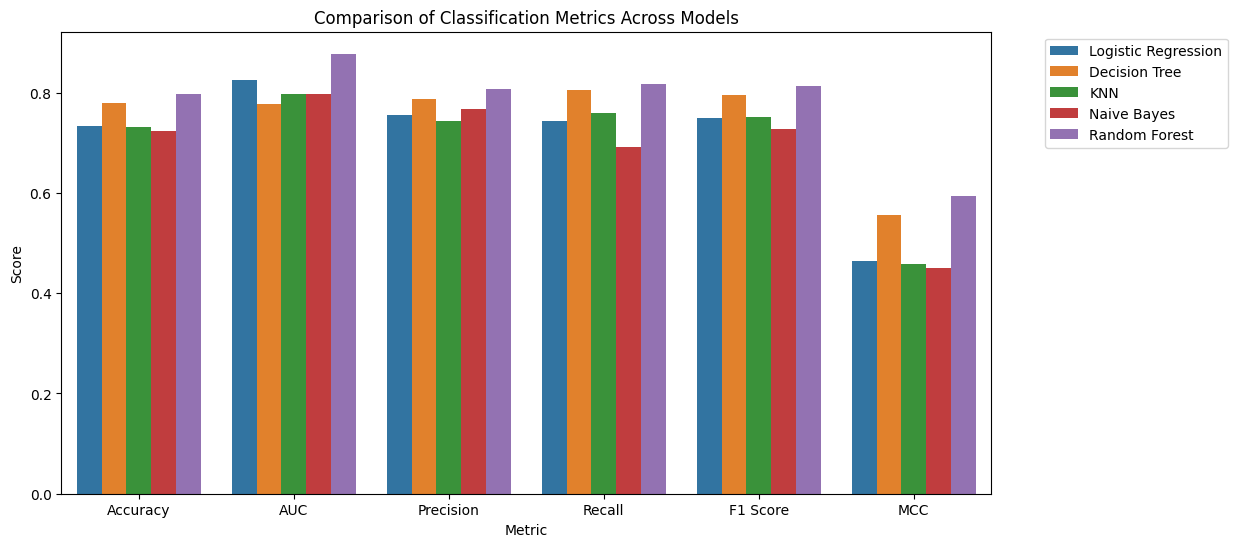

In [1]:
# 📌 Classification Models Evaluation Notebook

# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load Dataset directly from UCI (no local file needed)
#url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
#data = pd.read_csv(url, sep=";")
data = pd.read_csv("winequality-red.csv", sep=";")

print("Dataset Shape:", data.shape)
print("Features:", list(data.columns))

# Step 3: Prepare Data
X = data.iloc[:, :-1]   # Features
y = data.iloc[:, -1]    # Target (Wine Quality score)

# Convert to binary classification: Good (>=6) vs Bad (<6)
y = (y >= 6).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Step 4: Define Models (with scaling where needed)
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(max_iter=5000, solver='lbfgs'))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": Pipeline([
        ('scaler', StandardScaler()),   # scaling helps kNN
        ('knn', KNeighborsClassifier())
    ]),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Step 5: Train & Evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    try:
        y_prob = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_prob)
    except:
        auc = None
    
    results.append([name, acc, auc, prec, rec, f1, mcc])

# Step 6: Results Table
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "AUC", "Precision", "Recall", "F1 Score", "MCC"]
)
print("\nModel Performance Comparison:\n")
print(results_df)

# Step 7: Confusion Matrix for each model
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Step 8: Bar Chart Comparison of Metrics
metrics = ["Accuracy", "AUC", "Precision", "Recall", "F1 Score", "MCC"]
results_melted = results_df.melt(id_vars="Model", value_vars=metrics,
                                 var_name="Metric", value_name="Score")

plt.figure(figsize=(12,6))
sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")
plt.title("Comparison of Classification Metrics Across Models")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
